In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "prototype" / "src"))

from src.generators import generate_gift_recommendation
from src.model_config import get_available_models
from src.test_samples import get_test_profiles
from src.utils import load_env_from_repo_root

# Load .env file from repository root
load_env_from_repo_root(".env", override=True)

In [2]:
# # API_KEY="NsZEHgAXqIM66qVU" # fill this with the API Key from deployment setting

# # Initialize the OpenAI client with the vLLM API endpoint and your API key.
# client = OpenAI(
#     base_url="http://89.169.109.103:8000/v1/",
#     api_key=os.getenv("SANTA_SELF_HOSTED_1_API_KEY"),
# )

# completion = client.chat.completions.create(
#     model="deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
#     messages=[
#         {
#             "role": "user",
#             "content": """Hello!"""
#         }
#     ],
#     # temperature=0.8
# )

# print(completion.to_json())

In [3]:
"""Test self-hosted DeepSeek model for gift recommendation evaluation."""

from pathlib import Path

from src.data_scheme import KidProfile
from src.utils import load_env_from_repo_root

# Load environment variables
load_env_from_repo_root()

# Set up self-hosted model environment variables (if not already set)
# These would typically be in your .env file:
# SANTA_SELF_HOSTED_1_BASE_URL=http://89.169.109.103:8000/v1/
# SANTA_SELF_HOSTED_1_API_KEY=your_api_key_here
# SANTA_SELF_HOSTED_1_MODEL=deepseek-ai/DeepSeek-R1-Distill-Llama-8B
# SANTA_SELF_HOSTED_1_NAME=self-hosted-deepseek-r1

# Or set them programmatically for testing:
# if not os.getenv("SANTA_SELF_HOSTED_1_BASE_URL"):
#     os.environ["SANTA_SELF_HOSTED_1_BASE_URL"] = "http://89.169.109.103:8000/v1/"
#     os.environ["SANTA_SELF_HOSTED_1_API_KEY"] = os.getenv("SANTA_API_KEY", "")
#     os.environ["SANTA_SELF_HOSTED_1_MODEL"] = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
#     os.environ["SANTA_SELF_HOSTED_1_NAME"] = "self-hosted-deepseek-r1"


def test_self_hosted_deepseek():
    """Test gift recommendation generation with self-hosted DeepSeek model."""
    print("🔍 Testing self-hosted DeepSeek model for gift recommendations...\n")

    # Get available models (including self-hosted)
    models = get_available_models(include_self_hosted=True)

    # Create a test kid profile
    test_kid = KidProfile(name="Emma", age=7, wishlist=["doll", "art supplies", "books"])

    print("📝 Test Kid Profile:")
    print(f"   Name: {test_kid.name}")
    print(f"   Age: {test_kid.age}")
    print(f"   Wishlist: {', '.join(test_kid.wishlist)}\n")

    # Generate gift recommendation
    for model in models:
        print(model)

        try:
            recommendation, metrics = generate_gift_recommendation(
                llm_client=model.client, kid_profile=test_kid, temperature=0.8, max_tokens=300
            )

            print("✅ Success!\n")
            print("📊 Metrics:")
            print(f"   Latency: {metrics.get('latency_ms', 0):.2f} ms")
            print(f"   Tokens in: {metrics.get('tokens_in', 'N/A')}")
            print(f"   Tokens out: {metrics.get('tokens_out', 'N/A')}")
            print(f"   Model: {metrics.get('model', 'N/A')}\n")

            print("🎁 Recommended Gifts:")
            for i, gift in enumerate(recommendation.gifts, 1):
                print(f"   {i}. {gift}")

            print("\n💭 Rationale:")
            print(f"   {recommendation.rationale}\n")

        except Exception as e:
            print(f"❌ Error generating recommendation: {str(e)}")
            raise


test_self_hosted_deepseek()

🔍 Testing self-hosted DeepSeek model for gift recommendations...

📝 Test Kid Profile:
   Name: Emma
   Age: 7
   Wishlist: doll, art supplies, books

✅ Success!

📊 Metrics:
   Latency: 772.65 ms
   Tokens in: 222
   Tokens out: 90
   Model: deepseek-ai/DeepSeek-R1-Distill-Llama-8B

🎁 Recommended Gifts:
   1. Personalized Art Journal
   2. Interactive Storytime Book
   3. Cute Animal Doll Set

💭 Rationale:
   Emma's wishlist includes art supplies, so a personalized art journal would be perfect for her to express her creativity. An interactive storytime book adds a fun element, engaging her imagination. The cute animal doll set ties into her love for dolls, offering hours of playtime.



# Benchmark

In [4]:
from src.benchmark_llm import run_benchmark_suite

models = get_available_models(
    include_openai=True, include_token_factory=True, include_self_hosted=True
)
profiles = get_test_profiles()
print(profiles)

[KidProfile(id='52180e79-ea73-47e6-97c5-5d593001d88f', name='Emma', age=7, wishlist=['doll', 'art supplies', 'books']), KidProfile(id='a30027b0-42c8-4a8a-8c69-ee722d2c3b44', name='Lucas', age=10, wishlist=['LEGO set', 'video games', 'bicycle']), KidProfile(id='79d48754-727f-4aa1-a569-fd68f3e5bc14', name='Sophia', age=5, wishlist=['princess dress', 'stuffed animals']), KidProfile(id='f1a32d1f-e6c8-4637-bffd-e7b596858519', name='Noah', age=12, wishlist=['basketball', 'headphones', 'science kit'])]


In [13]:
import pandas as pd
from src.benchmark_llm import results_to_dataframe

result_frames = []

for concurrency in [1, 5, 10, 20]:
    results = run_benchmark_suite(models, profiles, concurrency=concurrency)
    result_frames.append(results_to_dataframe(results, concurrency=concurrency))

df = pd.concat(result_frames, ignore_index=True)
df

Starting benchmark suite with 5 models...
Using 4 test profiles
Concurrency level: 1

[1/5] Benchmarking gpt-4o-mini...
  ✓ Completed: 4/4 successful
[2/5] Benchmarking openai-gpt-3.5-turbo...
  ✓ Completed: 4/4 successful
[3/5] Benchmarking tf/gpt-oss-20b...
  ✓ Completed: 4/4 successful
[4/5] Benchmarking tf/DeepSeek-R1-0528...
  ✓ Completed: 4/4 successful
[5/5] Benchmarking santa-deepseek-r1...
  ✓ Completed: 4/4 successful
             model_name  latency_p50_ms  latency_p95_ms  latency_p99_ms  \
0           gpt-4o-mini     2928.086042     3731.291056     3731.291056   
1  openai-gpt-3.5-turbo     1295.558929     1364.270926     1364.270926   
2        tf/gpt-oss-20b     1449.583769     1543.210983     1543.210983   
3   tf/DeepSeek-R1-0528     4299.169779     4433.903217     4433.903217   
4     santa-deepseek-r1      798.029900     2256.210804     2256.210804   

   throughput_tokens_per_sec  tokens_in_avg  tokens_out_avg  success_rate  \
0                 117.507907         220

,model_name,latency_p50_ms,latency_p95_ms,latency_p99_ms,throughput_tokens_per_sec,tokens_in_avg,tokens_out_avg,success_rate,total_requests,successful_requests,cost_per_1m_in,cost_per_1m_out,cost_per_1m_in_throughput_based,cost_per_1m_out_throughput_based,cost_1m_requests,cost_1m_requests_throughput_based,concurrency
0,gpt-4o-mini,2928.086042,3731.291056,3731.291056,117.507907,220.00,125.75,1.0,4,4,0.15,0.60,NaN,NaN,108.0,NaN,1
1,openai-gpt-3.5-turbo,1295.558929,1364.270926,1364.270926,354.944648,224.00,93.25,1.0,4,4,1.50,2.00,NaN,NaN,522.0,NaN,1
2,tf/gpt-oss-20b,1449.583769,1543.210983,1543.210983,174.391361,282.00,269.25,1.0,4,4,0.15,0.60,NaN,NaN,204.0,NaN,1
3,tf/DeepSeek-R1-0528,4299.169779,4433.903217,4433.903217,82.095151,226.25,101.50,1.0,4,4,0.80,2.40,NaN,NaN,423.0,NaN,1
4,santa-deepseek-r1,798.029900,2256.210804,2256.210804,433.121308,222.00,141.00,1.0,4,4,4.21,6.62,2.73,2.73,1868.0,990.99,1
5,gpt-4o-mini,3050.440073,3292.521000,3292.521000,266.912008,220.00,122.25,1.0,4,4,0.15,0.60,NaN,NaN,106.0,NaN,5
6,openai-gpt-3.5-turbo,1267.735004,1334.812880,1334.812880,1454.417149,224.00,93.00,1.0,4,4,1.50,2.00,NaN,NaN,522.0,NaN,5
7,tf/gpt-oss-20b,1331.825972,1438.880920,1438.880920,872.076026,282.00,261.75,1.0,4,4,0.15,0.60,NaN,NaN,199.0,NaN,5
8,tf/DeepSeek-R1-0528,5666.655302,7179.378033,7179.378033,259.235159,226.25,109.75,1.0,4,4,0.80,2.40,NaN,NaN,442.0,NaN,5
9,santa-deepseek-r1,740.194082,854.989767,854.989767,1604.665093,222.00,81.75,1.0,4,4,2.66,7.29,0.74,0.74,1181.0,224.22,5


## Plots

/var/folders/pb/tn1_xgrn17qfr6nn7gsbz1c40000gn/T/ipykernel_80391/3777432655.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


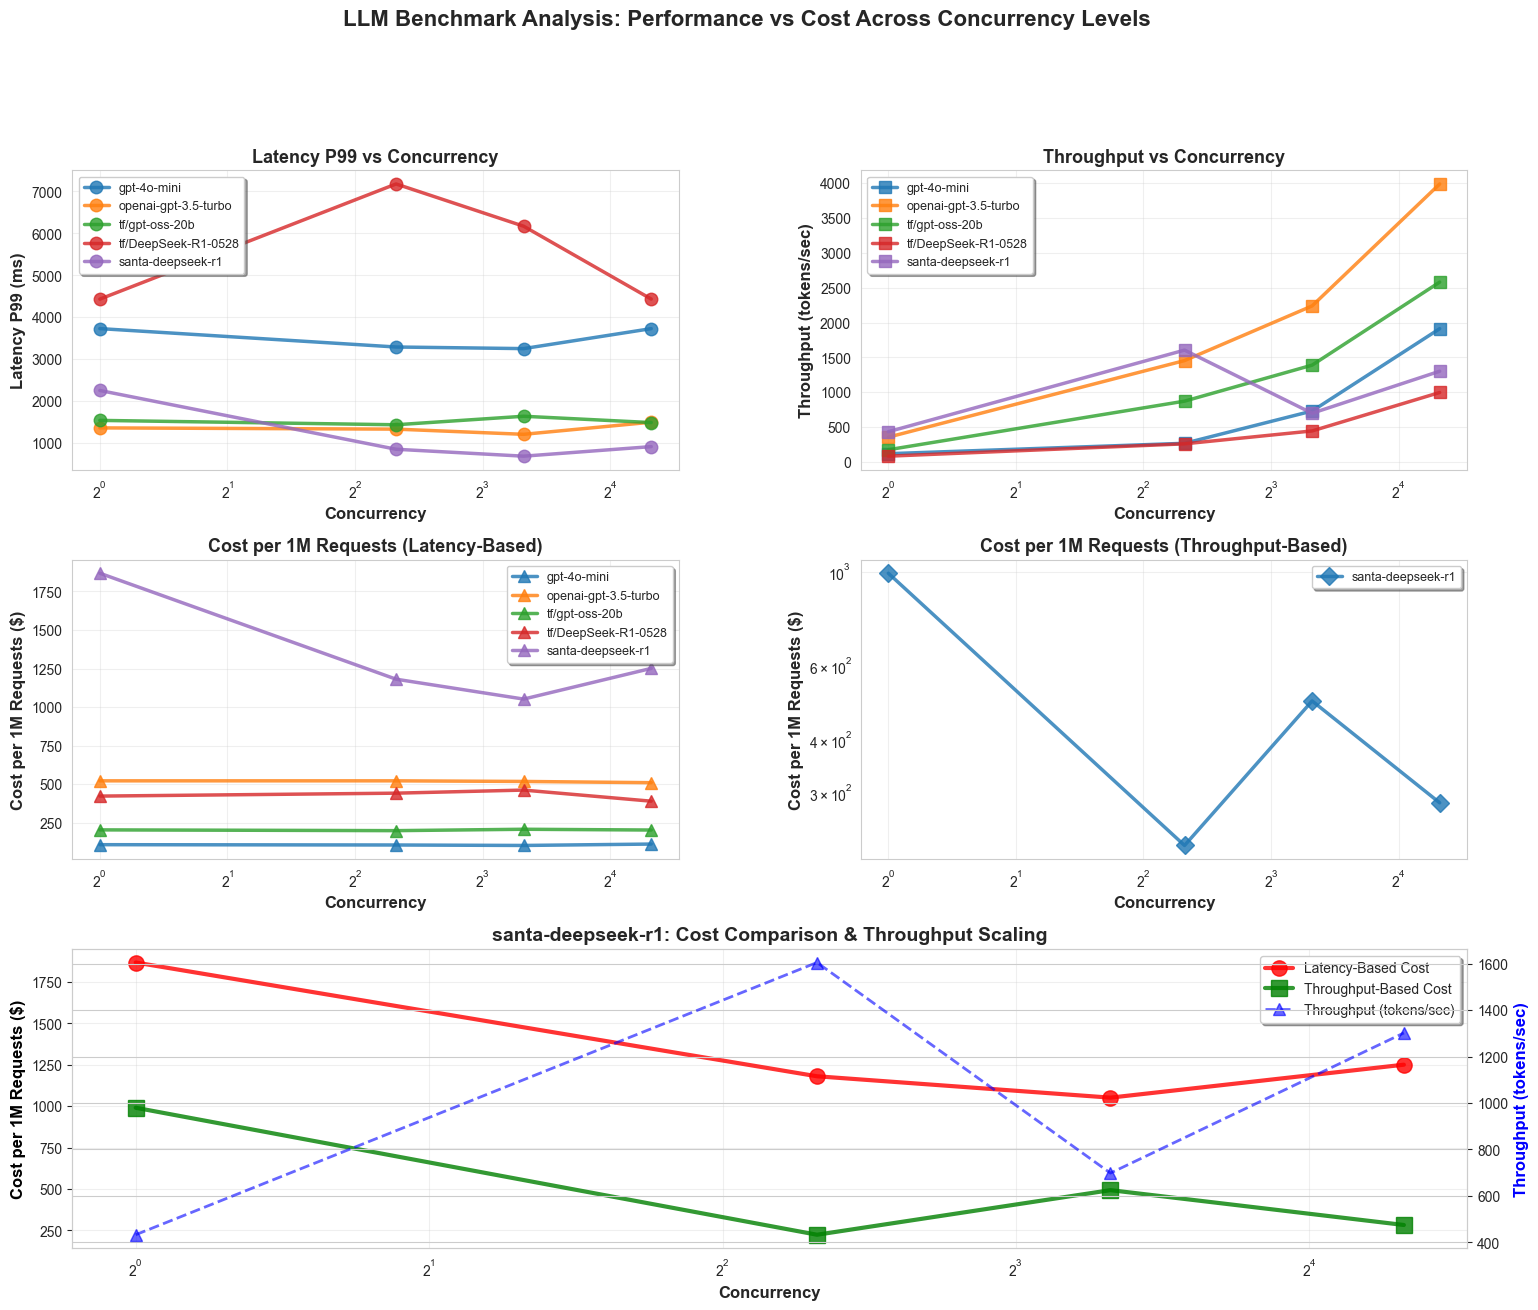


DETAILED ANALYSIS

📊 Cost Efficiency Analysis (Throughput-Based):
--------------------------------------------------------------------------------

santa-deepseek-r1:
  Best throughput: 1604.7 tok/s at concurrency=5
  Best cost: $224 per 1M requests at concurrency=5
  Latency P99 at best cost: 855.0 ms


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 12)

# Assuming df is your combined DataFrame with all concurrency levels
# If not, combine: df = pd.concat(result_frames, ignore_index=True)

# Create comprehensive analysis plots
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Latency P99 vs Concurrency
ax1 = fig.add_subplot(gs[0, 0])
for model in df["model_name"].unique():
    model_data = df[df["model_name"] == model].sort_values("concurrency")
    ax1.plot(
        model_data["concurrency"],
        model_data["latency_p99_ms"],
        marker="o",
        label=model,
        linewidth=2.5,
        markersize=9,
        alpha=0.8,
    )

ax1.set_xlabel("Concurrency", fontsize=12, fontweight="bold")
ax1.set_ylabel("Latency P99 (ms)", fontsize=12, fontweight="bold")
ax1.set_title("Latency P99 vs Concurrency", fontsize=13, fontweight="bold")
ax1.legend(loc="best", frameon=True, shadow=True, fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xscale("log", base=2)

# 2. Throughput vs Concurrency
ax2 = fig.add_subplot(gs[0, 1])
for model in df["model_name"].unique():
    model_data = df[df["model_name"] == model].sort_values("concurrency")
    ax2.plot(
        model_data["concurrency"],
        model_data["throughput_tokens_per_sec"],
        marker="s",
        label=model,
        linewidth=2.5,
        markersize=9,
        alpha=0.8,
    )

ax2.set_xlabel("Concurrency", fontsize=12, fontweight="bold")
ax2.set_ylabel("Throughput (tokens/sec)", fontsize=12, fontweight="bold")
ax2.set_title("Throughput vs Concurrency", fontsize=13, fontweight="bold")
ax2.legend(loc="best", frameon=True, shadow=True, fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xscale("log", base=2)

# 3. Cost per 1M Requests (Latency-Based) vs Concurrency
ax3 = fig.add_subplot(gs[1, 0])
for model in df["model_name"].unique():
    model_data = df[df["model_name"] == model].sort_values("concurrency")
    ax3.plot(
        model_data["concurrency"],
        model_data["cost_1m_requests"],
        marker="^",
        label=model,
        linewidth=2.5,
        markersize=9,
        alpha=0.8,
    )

ax3.set_xlabel("Concurrency", fontsize=12, fontweight="bold")
ax3.set_ylabel("Cost per 1M Requests ($)", fontsize=12, fontweight="bold")
ax3.set_title("Cost per 1M Requests (Latency-Based)", fontsize=13, fontweight="bold")
ax3.legend(loc="best", frameon=True, shadow=True, fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xscale("log", base=2)

# 4. Cost per 1M Requests (Throughput-Based) vs Concurrency
ax4 = fig.add_subplot(gs[1, 1])
for model in df["model_name"].unique():
    model_data = df[df["model_name"] == model].sort_values("concurrency")
    # Filter out NaN and zero values for better visualization
    valid_data = model_data[model_data["cost_1m_requests_throughput_based"].notna()]
    if not valid_data.empty:
        # Show actual values, not rounded zeros
        ax4.plot(
            valid_data["concurrency"],
            valid_data["cost_1m_requests_throughput_based"],
            marker="D",
            label=model,
            linewidth=2.5,
            markersize=9,
            alpha=0.8,
        )
        # Add annotation for zero values explaining they're < $0.50
        zero_data = model_data[
            (model_data["cost_1m_requests_throughput_based"] == 0.0)
            | (model_data["cost_1m_requests_throughput_based"].isna())
        ]
        if not zero_data.empty:
            for _, row in zero_data.iterrows():
                ax4.annotate(
                    "< $0.50", xy=(row["concurrency"], 50), fontsize=8, alpha=0.6, ha="center"
                )

ax4.set_xlabel("Concurrency", fontsize=12, fontweight="bold")
ax4.set_ylabel("Cost per 1M Requests ($)", fontsize=12, fontweight="bold")
ax4.set_title("Cost per 1M Requests (Throughput-Based)", fontsize=13, fontweight="bold")
ax4.legend(loc="best", frameon=True, shadow=True, fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xscale("log", base=2)
ax4.set_yscale("log")  # Log scale to show the dramatic improvement

# 5. santa-deepseek-r1: Latency vs Throughput Cost Comparison
ax5 = fig.add_subplot(gs[2, :])
santa_data = df[df["model_name"] == "santa-deepseek-r1"].sort_values("concurrency")
if not santa_data.empty:
    ax5_twin = ax5.twinx()

    # Latency-based cost (left axis)
    line1 = ax5.plot(
        santa_data["concurrency"],
        santa_data["cost_1m_requests"],
        marker="o",
        label="Latency-Based Cost",
        linewidth=3,
        markersize=11,
        color="red",
        alpha=0.8,
    )

    # Throughput-based cost (left axis, but use different scale)
    valid_throughput = santa_data[santa_data["cost_1m_requests_throughput_based"].notna()]
    line2 = ax5.plot(
        valid_throughput["concurrency"],
        valid_throughput["cost_1m_requests_throughput_based"],
        marker="s",
        label="Throughput-Based Cost",
        linewidth=3,
        markersize=11,
        color="green",
        alpha=0.8,
    )

    # Throughput on right axis
    line3 = ax5_twin.plot(
        santa_data["concurrency"],
        santa_data["throughput_tokens_per_sec"],
        marker="^",
        label="Throughput (tokens/sec)",
        linewidth=2,
        markersize=9,
        color="blue",
        alpha=0.6,
        linestyle="--",
    )

    ax5.set_xlabel("Concurrency", fontsize=12, fontweight="bold")
    ax5.set_ylabel("Cost per 1M Requests ($)", fontsize=12, fontweight="bold", color="black")
    ax5_twin.set_ylabel("Throughput (tokens/sec)", fontsize=12, fontweight="bold", color="blue")
    ax5.set_title(
        "santa-deepseek-r1: Cost Comparison & Throughput Scaling", fontsize=14, fontweight="bold"
    )
    ax5.set_xscale("log", base=2)
    ax5.grid(True, alpha=0.3)

    # Combine legends
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax5.legend(lines, labels, loc="upper right", frameon=True, shadow=True)

plt.suptitle(
    "LLM Benchmark Analysis: Performance vs Cost Across Concurrency Levels",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "=" * 80)
print("DETAILED ANALYSIS")
print("=" * 80)

# Cost efficiency analysis
print("\n📊 Cost Efficiency Analysis (Throughput-Based):")
print("-" * 80)
for model in df["model_name"].unique():
    model_data = df[df["model_name"] == model].sort_values("concurrency")
    best_throughput = model_data.loc[model_data["throughput_tokens_per_sec"].idxmax()]
    best_cost = model_data[
        model_data["cost_1m_requests_throughput_based"].notna()
        & (model_data["cost_1m_requests_throughput_based"] > 0)
    ]

    if not best_cost.empty:
        best_cost_row = best_cost.loc[best_cost["cost_1m_requests_throughput_based"].idxmin()]
        print(f"\n{model}:")
        print(
            f"  Best throughput: {best_throughput['throughput_tokens_per_sec']:.1f} tok/s at concurrency={best_throughput['concurrency']}"
        )
        if not best_cost.empty:
            print(
                f"  Best cost: ${best_cost_row['cost_1m_requests_throughput_based']:.0f} per 1M requests at concurrency={best_cost_row['concurrency']}"
            )
            print(f"  Latency P99 at best cost: {best_cost_row['latency_p99_ms']:.1f} ms")